In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_plane)=
# Get plane

*Fitting unweighted planes and measuring orthogonal deviations.*

A plane is a geometric feature of an atom selection, independent of connectivity or aromaticity. The experimental tool reports a centroid, an unoriented unit normal and two planarity measures for each group and structure.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.structure.get_plane` for the full argument and output contract.
:::

## Basic usage

Let's show how this function works with the side-chain ring of a phenylalanine in bundled T4 lysozyme. Here we supply its six atom indices explicitly; plane fitting itself does not identify aromatic chemistry.

In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt
from molsysmt import pyunitwizard as puw
from molsysmt.native import Structures

In [3]:
molsys = msm.convert(msm.systems['T4 lysozyme L99A']['181l.h5msm'], to_form='molsysmt.MolSys')
phe_group = msm.select(molsys, element='group', selection='group_name=="PHE"')[0]
ring = msm.select(molsys, selection=f'group_index=={phe_group} and atom_name in ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"]')
plane = msm.structure.get_plane(molsys, selection=ring)
print('Source atom indices:', plane['atom_indices'])
print('Center:', plane['centers'])
print('Normal:', plane['normals'])
print('RMS deviation:', plane['rms_deviation'])

Source atom indices: [29 30 31 32 33 34]
Center: [[[3.8094499905904136 0.28298333287239075 1.703516681989034]]] nanometer
Normal: [[[ 0.51819971 -0.41751852  0.74642303]]]
RMS deviation: [[0.0006737517112770234]] nanometer


:::{note} Demo Systems Catalog
:class: dropdown

Explore bundled examples in {ref}`Demo Systems <user-foundations-entrance-demo-systems>`.
:::

## Multiple groups

Supply nested selections for separate planes. Groups may overlap. Repeated atoms within a group are removed because each atom has equal weight; group order is retained. At least three distinct atoms are required per group.

In [4]:
planes = msm.structure.get_plane(molsys, selection=[ring, ring[:3]])
print('Normal array shape:', planes['normals'].shape)
print('Membership offsets:', planes['atom_offsets'])

Normal array shape: (1, 2, 3)
Membership offsets: [0 6 9]


## Planarity over structures

Use this controlled geometric ensemble to see how increasing displacement of one atom changes planarity. These synthetic coordinates are an illustration, not a simulation or an aromaticity declaration. Length inputs carry explicit units.

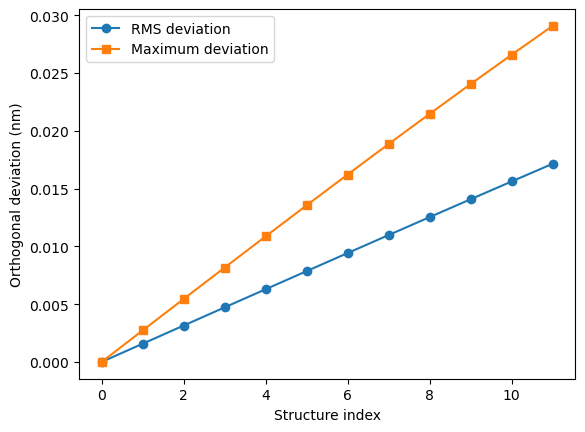

In [5]:
angles = np.arange(6) * np.pi / 3
xyz = np.zeros((12, 6, 3))
xyz[:, :, :2] = .14 * np.column_stack((np.cos(angles), np.sin(angles)))
xyz[:, 0, 2] = np.linspace(0, .06, len(xyz))
molsys = Structures(coordinates=puw.quantity(xyz, 'nm'))
planes = msm.structure.get_plane(molsys, heavy_mode='force')
rms = puw.get_value(planes['rms_deviation'], to_unit='nm')[:, 0]
maximum = puw.get_value(planes['max_deviation'], to_unit='nm')[:, 0]
fig, ax = plt.subplots()
ax.plot(planes['structure_indices'], rms, marker='o', label='RMS deviation')
ax.plot(planes['structure_indices'], maximum, marker='s', label='Maximum deviation')
ax.set(xlabel='Structure index', ylabel='Orthogonal deviation (nm)')
ax.legend();

## Source indices and units

Nonconsecutive structure indices retain their requested order and repetitions; they are not structure IDs. Empty frame lists return arrays with zero on the frame axis. Centers and deviations are length quantities standardized to session units; normals are dimensionless NumPy arrays. Convert lengths explicitly when comparing results.

In [6]:
subset = msm.structure.get_plane(molsys, structure_indices=[10, 1, 10])
print('Requested structures:', subset['structure_indices'])
print('Centers in angstrom:', puw.get_value(subset['centers'], to_unit='angstrom').shape)
empty = msm.structure.get_plane(molsys, structure_indices=[])
print('Empty normals:', empty['normals'].shape)

Requested structures: [10  1 10]
Centers in angstrom: (3, 1, 3)
Empty normals: (0, 1, 3)


## Periodic participants

When requesting PBC validation, supply finite nonsingular boxes. Every atom of a group must already lie in the anchor atom's minimum-image neighborhood. The tool does not reconstruct molecules across the box or modify source coordinates. Uniform image translations of a complete group retain its observed centroid.

In [7]:
molsys.box = puw.quantity(np.repeat(np.eye(3)[None], len(xyz), axis=0), 'nm')
periodic = msm.structure.get_plane(molsys, pbc=True, structure_indices=[0, 10])
print('Validated periodic normals:', periodic['normals'].shape)
split_xyz = xyz[:1].copy()
split_xyz[0, 0, 0] += 1
split = Structures(coordinates=puw.quantity(split_xyz, 'nm'), box=puw.quantity(np.eye(3)[None], 'nm'))
try:
    msm.structure.get_plane(split, pbc=True)
except msm.NotImplementedMethodError:
    print('Split group rejected: reconstruct participants first.')

Validated periodic normals: (2, 1, 3)
Split group rejected: reconstruct participants first.


## Degeneracy and orientation

A unique normal requires a gap between the smallest and middle singular values. Coincident atoms, collinear selections and isotropic clouds fail explicitly. Equal in-plane singular values, as in a regular planar ring, are allowed. A largest-component-positive sign convention is deterministic but does not ensure sign continuity over time. For the angle between unoriented planes, use the absolute normal dot product.

In [8]:
normals = planes['normals'][:, 0]
cosine = np.clip(np.abs(normals @ normals[0]), 0, 1)
print('Angles from first plane (radians):', np.arccos(cosine).round(4))
collinear = Structures(coordinates=puw.quantity(np.array([[[0., 0., 0.], [.1, 0., 0.], [.2, 0., 0.]]]), 'nm'))
try:
    msm.structure.get_plane(collinear)
except msm.StructuralInconsistencyError:
    print('Collinear selection rejected: no unique normal.')

Angles from first plane (radians): [0.     0.013  0.026  0.039  0.0521 0.0653 0.0785 0.0918 0.1052 0.1187
 0.1324 0.1462]
Collinear selection rejected: no unique normal.


## Streaming coordinate input

`heavy_mode='auto'` chooses coordinate blocks when the estimated numerical work cannot fit eagerly. `'force'` requests the source form's declared streaming route; `'off'` requests eager work and still checks the numerical budget. Native Structures/MolSys and H5MSM 0.5 support projection. Other forms providing coordinates can use the eager getter route; unavailable streaming fails explicitly.

An H5MSM 0.5 file needs only Structures for this calculation. Explicit atom and frame indices avoid loading topology or saved interaction analyses. Rich selections can require ordinary full-system selection. Dense output remains in RAM: budget checks cover estimated numeric buffers, not process RSS. This result is geometric data, not a persisted Interactions analysis.

:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>` — converting forms; {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>` — selecting source indices; {func}`molsysmt.basic.select`.
- {ref}`Get plane <Tutorial_Get_plane>` — fitting selected groups; {func}`molsysmt.structure.get_plane`.
:::